# 🍷 Wine Quality Classification
## Análise Exploratória de Dados (EDA)

**Objetivo:** Investigar a distribuição das variáveis, identificar correlações,
detectar outliers e analisar o balanceamento das classes.

**Dataset:** WineQT.csv — 1.143 amostras, 12 variáveis físico-químicas  
**Variável alvo:** `quality` → transformada em classificação binária (≥7 = Alta Qualidade)

---

In [62]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from evaluation import avaliar_modelo

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

import warnings
warnings.filterwarnings("ignore")

---
## 1. Carregamento e Inspeção Inicial

O dataset WineQT.csv reúne 1.143 amostras de vinho tinto com 12 variáveis físico-químicas
e uma variável de qualidade avaliada por sommeliers. A inspeção inicial valida estrutura,
tipos e integridade dos dados antes da análise.

In [63]:
df = pd.read_csv("../data/WineQT.csv")

print(f"Shape: {df.shape[0]} linhas x {df.shape[1]} colunas")
print()
print("Tipos de dados:")
print(df.dtypes)
print()
df.head()

Shape: 1143 linhas x 13 colunas

Tipos de dados:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


---
## 2. Qualidade dos Dados

Verificação de valores nulos e duplicatas.

In [64]:
print(f"Valores nulos: {df.isnull().sum().sum()}")
print(f"Linhas duplicadas: {df.duplicated().sum()}")
df.describe().round(2)

Valores nulos: 0
Linhas duplicadas: 0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00
mean,8.31,0.53,0.27,2.53,0.09,15.62,45.91,1.00,3.31,0.66,10.44,5.66,804.97
std,1.75,0.18,0.20,1.36,0.05,10.25,32.78,0.00,0.16,0.17,1.08,0.81,464.00
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00,0.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,21.00,1.00,3.20,0.55,9.50,5.00,411.00
50%,7.90,0.52,0.25,2.20,0.08,13.00,37.00,1.00,3.31,0.62,10.20,6.00,794.00
75%,9.10,0.64,0.42,2.60,0.09,21.00,61.00,1.00,3.40,0.73,11.10,6.00,1209.50
max,15.90,1.58,1.00,15.50,0.61,68.00,289.00,1.00,4.01,2.00,14.90,8.00,1597.00


> **Conclusão:** Nenhum valor nulo ou duplicata identificado.

---
## 3. Transformação da Variável Alvo

A variável quality possui notas de 3 a 8. Para a classificação binária,
vinhos com nota ≥ 7 são classificados como Alta Qualidade (1) e os demais como
Baixa/Média Qualidade (0).

In [65]:
df["quality_binary"] = (df["quality"] >= 7).astype(int)

contagem = df["quality_binary"].value_counts()
proporcao = df["quality_binary"].value_counts(normalize=True) * 100

resumo = pd.DataFrame({
    "Classe": ["Baixa/Média Qualidade (< 7)", "Alta Qualidade (≥ 7)"],
    "Amostras": [contagem[0], contagem[1]],
    "Proporção (%)": [proporcao[0].round(1), proporcao[1].round(1)]
})

print(resumo.to_string(index=False))

                     Classe  Amostras  Proporção (%)
Baixa/Média Qualidade (< 7)       984           86.1
       Alta Qualidade (≥ 7)       159           13.9


---
## 4. Análise Exploratória de Dados (EDA)

### 4.1 Balanceamento das Classes

Visualização da distribuição entre as classes Alta Qualidade e Baixa/Média Qualidade.

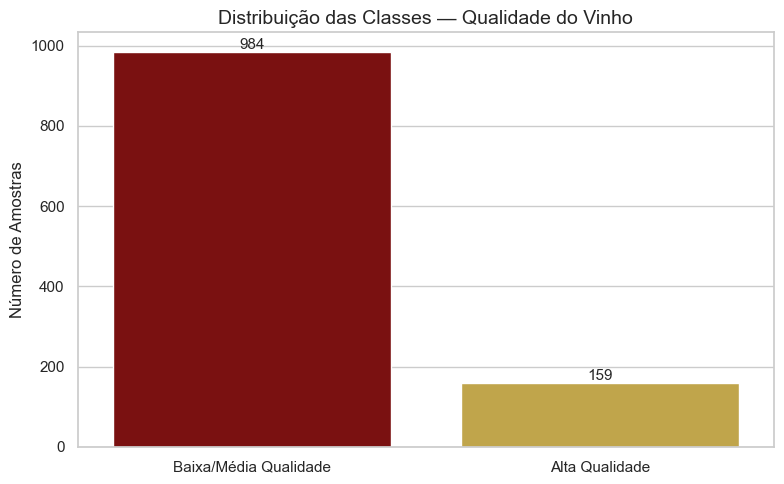

In [66]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(data=df, x="quality_binary", palette=["#8B0000", "#D4AF37"], ax=ax)

ax.set_xticklabels(["Baixa/Média Qualidade", "Alta Qualidade"])
ax.set_xlabel("")
ax.set_ylabel("Número de Amostras")
ax.set_title("Distribuição das Classes — Qualidade do Vinho")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.savefig("../results/figures/01_distribuicao_classes.png", dpi=300)
plt.show()

### 4.2 Distribuição das Variáveis Físico-Químicas

Histogramas das demais features, para identificar distribuição,
assimetria e presença de outliers.

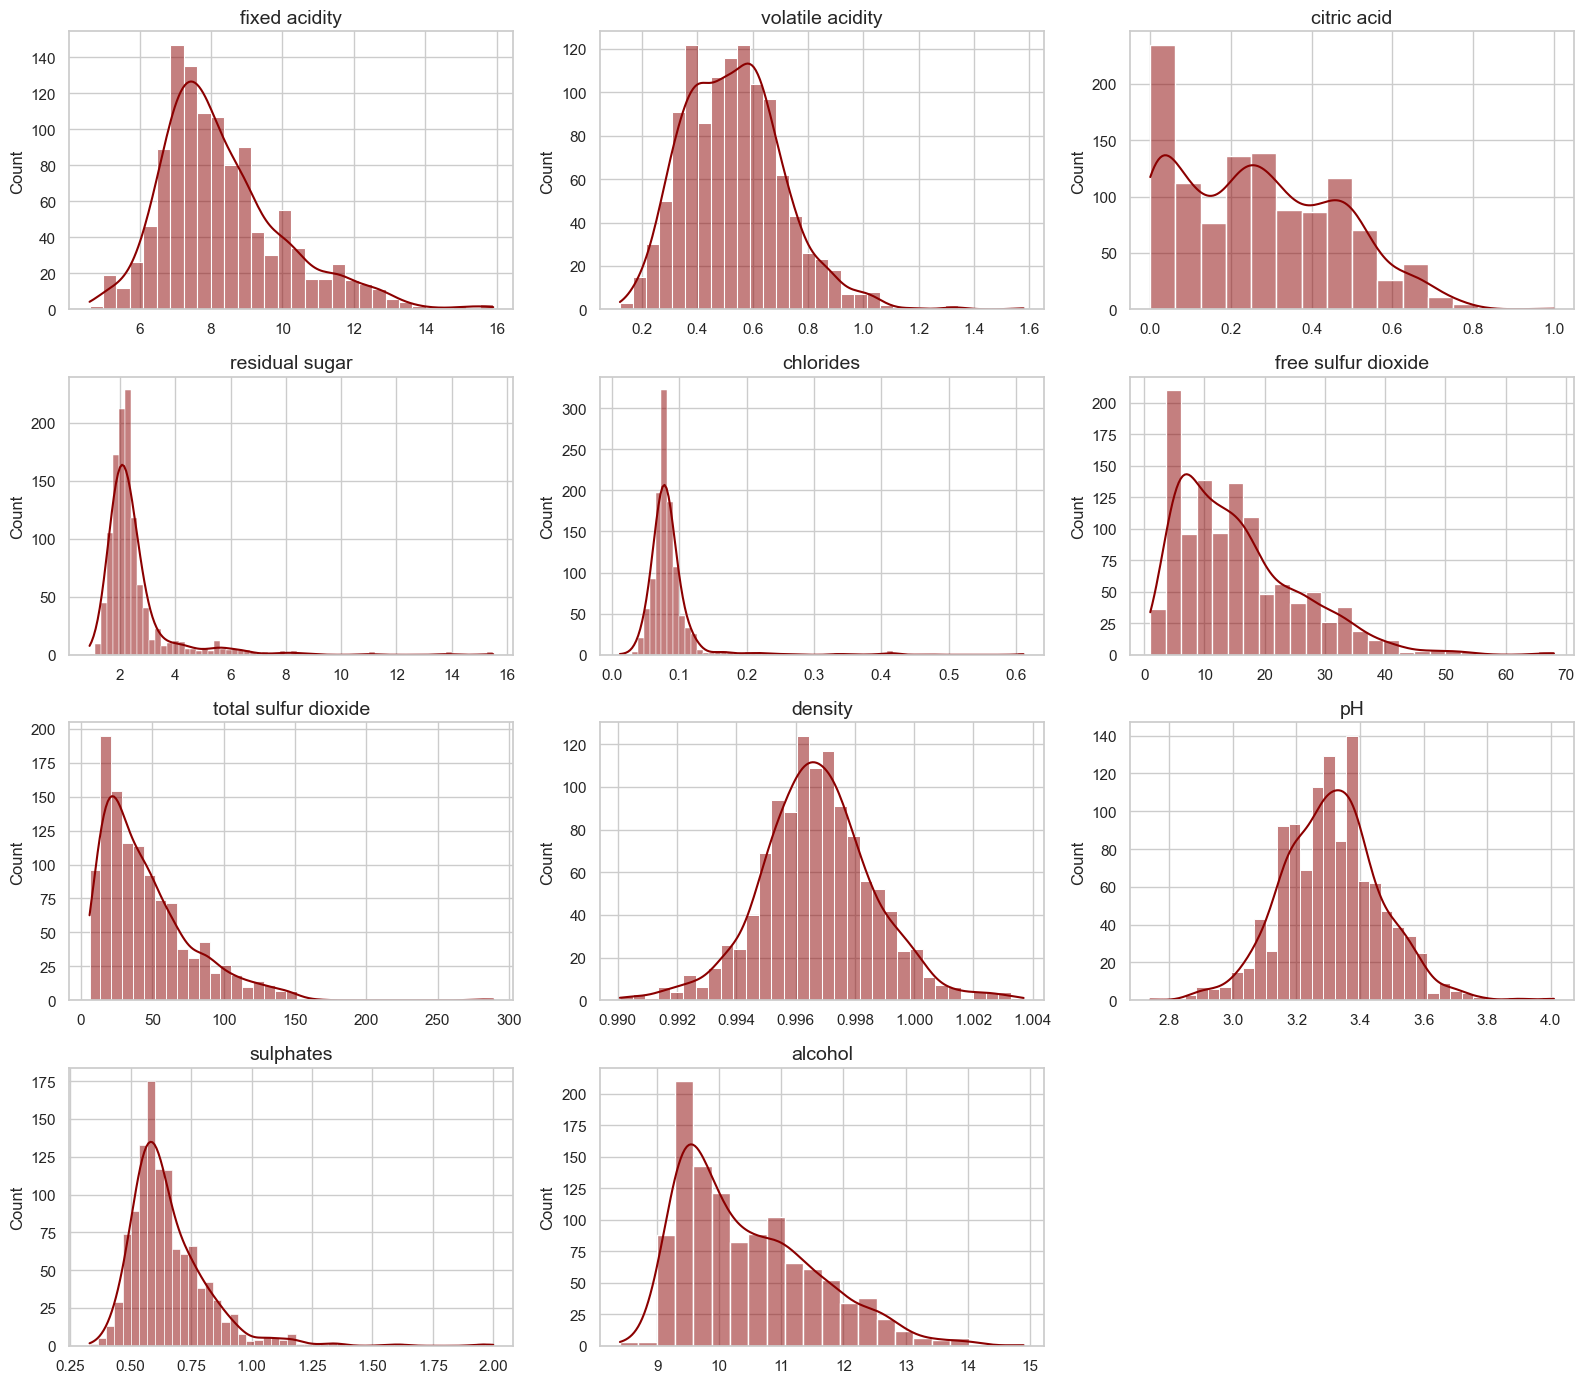

In [67]:
features = df.columns.drop(["Id", "quality", "quality_binary"])

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color="#8B0000")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig("../results/figures/02_distribuicao_features.png", dpi=300)
plt.show()

**Observação:** `citric acid` apresenta distribuição assimétrica, distinta do
padrão aproximadamente normal das demais features. Será revisto
na análise de outliers.

### 4.3 Matriz de Correlação

Correlação de Pearson entre todas as variáveis e a qualidade, olhando tanto a
relação com o alvo quanto entre as próprias features.

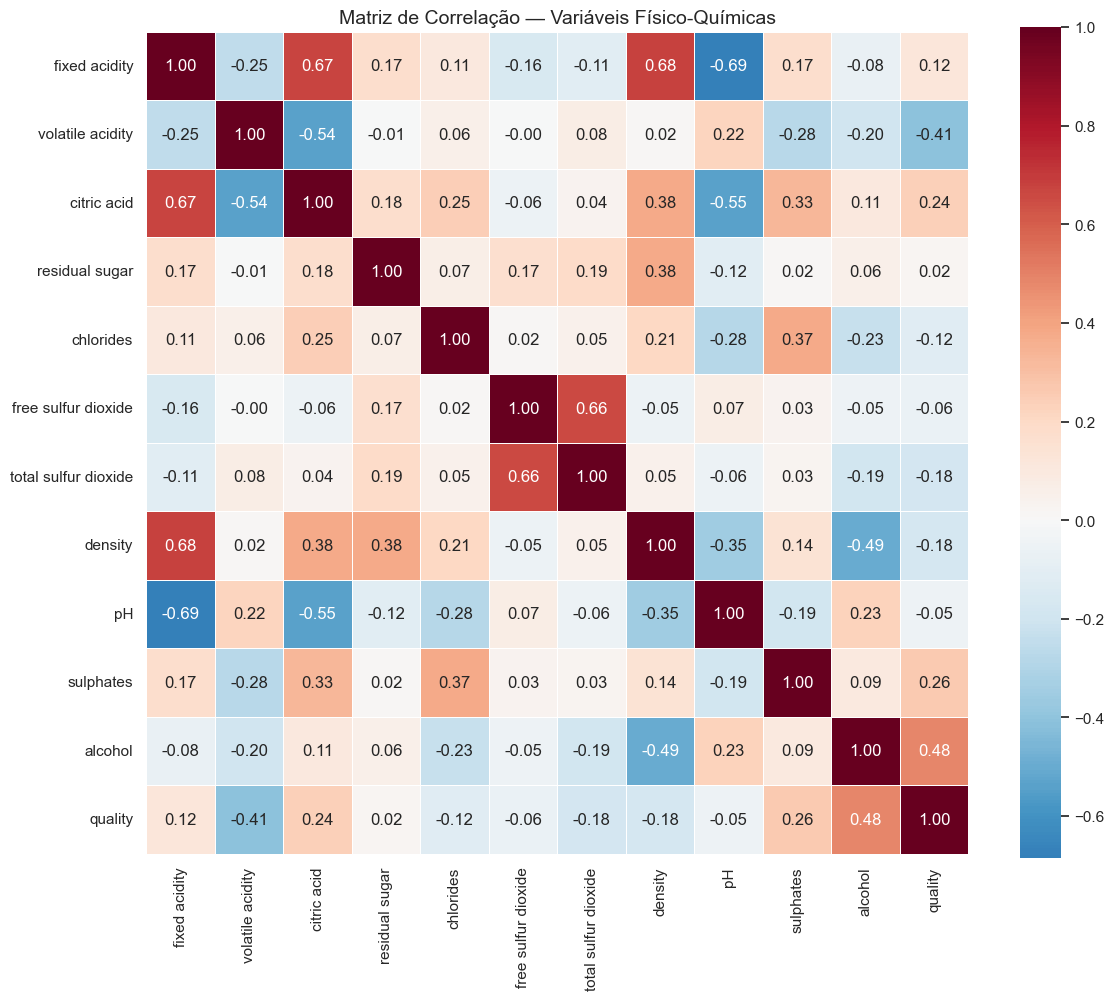

In [68]:
corr_matrix = df.drop(columns=["Id", "quality_binary"]).corr()

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Matriz de Correlação — Variáveis Físico-Químicas")

plt.tight_layout()
plt.savefig("../results/figures/03_matriz_correlacao.png", dpi=300)
plt.show()

**Interpretação da Matriz de Correlação:**

Maior correlação com `quality`: `alcohol` (0.48) e `volatile acidity` (-0.41),
seguidos por `sulphates` (0.26) e `citric acid` (0.24).

Pares de features com correlação alta entre si (possível multicolinearidade):
- `fixed acidity` × `pH` (-0.69)
- `free sulfur dioxide` × `total sulfur dioxide` (0.66) — SO₂ livre é subconjunto
  do SO₂ total por definição, então essa correlação é esperada.
- `fixed acidity` × `citric acid` (0.67)

A relação entre acidez e pH foi validada com pesquisa de domínio: pH mede a
intensidade da acidez, não a quantidade, o que explica por que a correlação é
forte mas não perfeita *(Wine Fun; Reserva85)*.

### 4.4 Detecção de Outliers

Boxplots de cada feature para identificação de outliers.

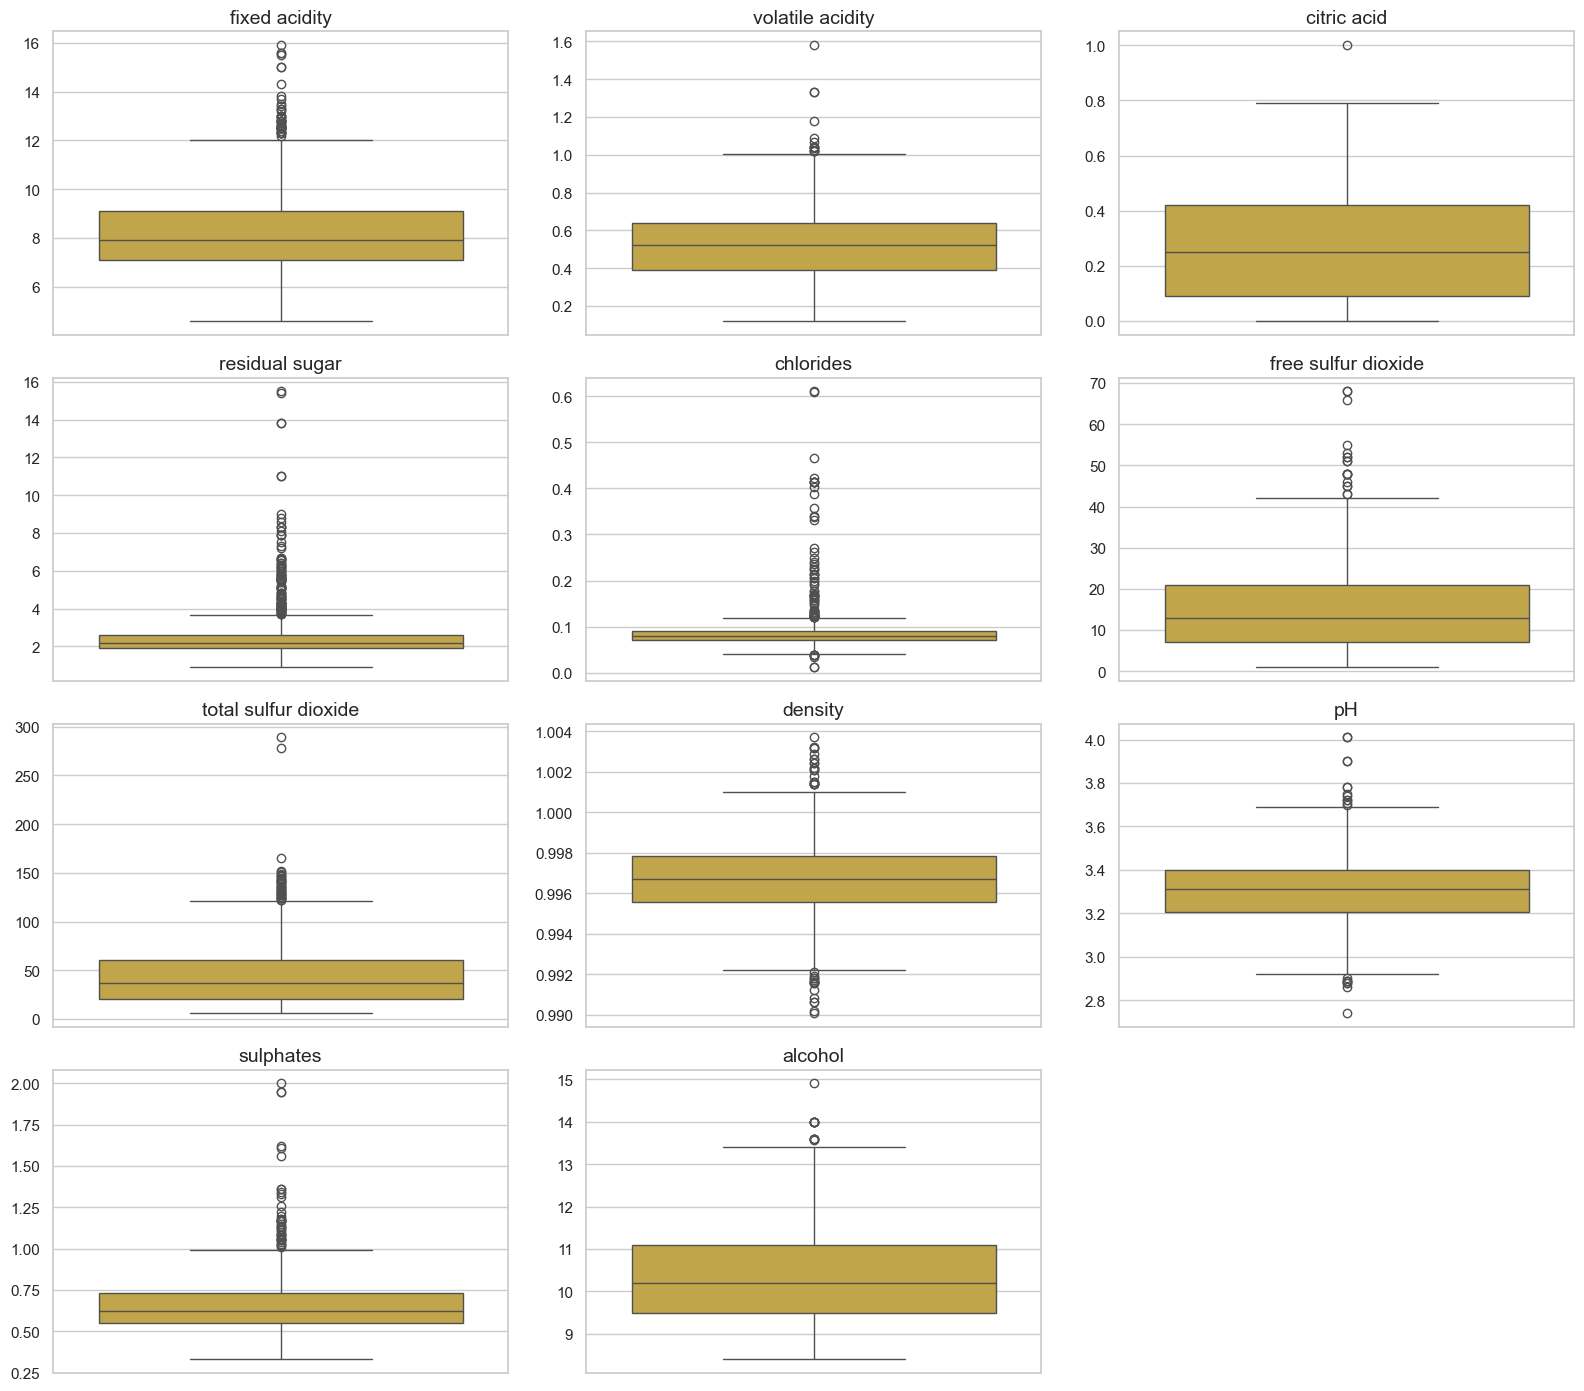

In [69]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, y=col, ax=axes[i], color="#D4AF37")
    axes[i].set_title(col)
    axes[i].set_ylabel("")

fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig("../results/figures/04_boxplots_outliers.png", dpi=300)
plt.show()

### 4.5 Distribuição das Features por Classe

Comparação da distribuição de cada feature entre as classes Alta Qualidade (1) e
Baixa/Média Qualidade (0), identificando quais variáveis apresentam separação
estatística relevante entre os grupos.

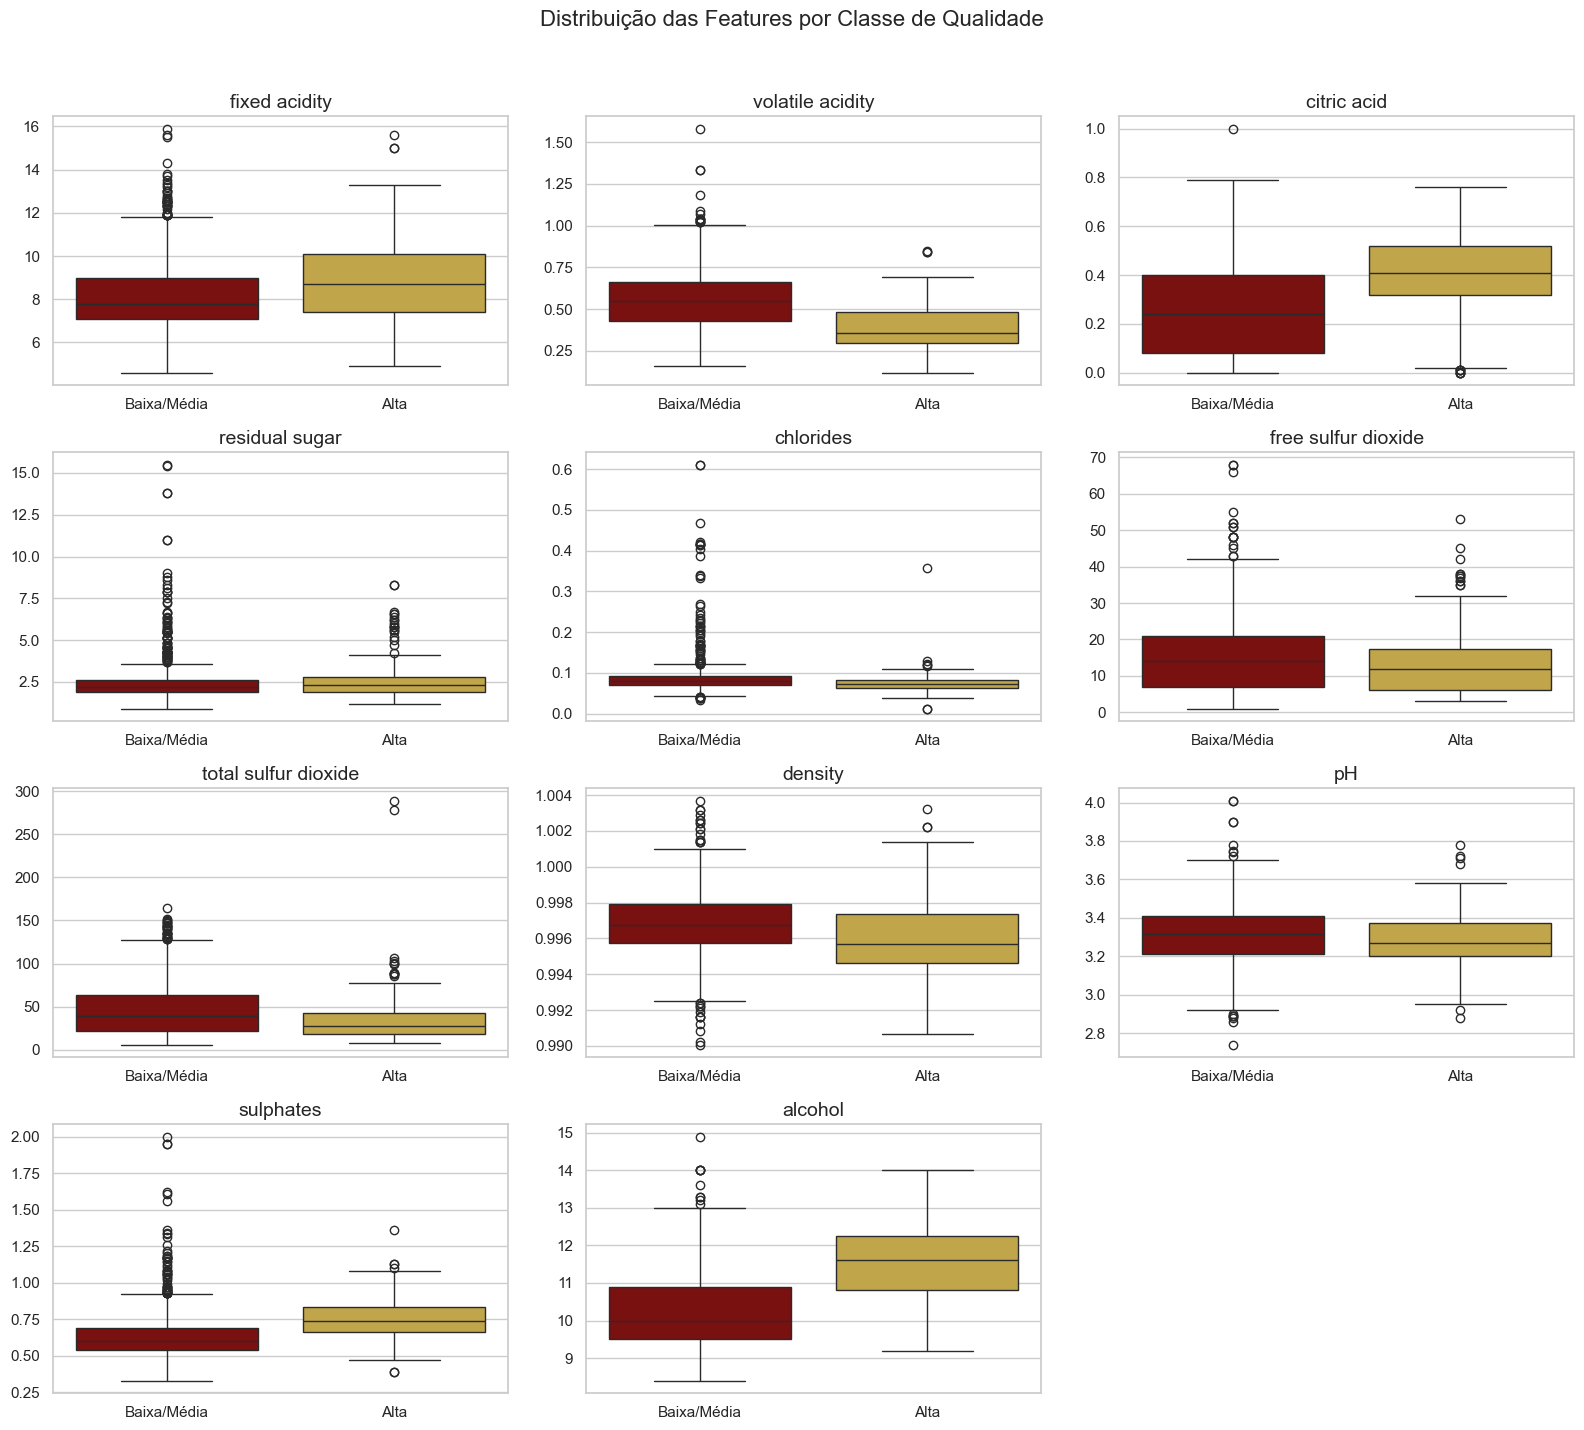

In [70]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(
    data=df.assign(quality_binary=df["quality_binary"].astype(str)),
    x="quality_binary",
    y=col,
    palette={"0": "#8B0000", "1": "#D4AF37"},
    order=["0", "1"],
    ax=axes[i]

    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_xticklabels(["Baixa/Média", "Alta"])
    axes[i].set_ylabel("")

fig.delaxes(axes[-1])

plt.suptitle("Distribuição das Features por Classe de Qualidade", 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/05_features_por_classe.png", dpi=300)
plt.show()

**Interpretação — Features por Classe:**

As quatro variáveis com separação mais visível entre as classes foram `alcohol`,
`volatile acidity`, `sulphates` e `citric acid`. Em todas elas a caixa de "Alta
Qualidade" aparece deslocada da caixa de "Baixa/Média" — alcohol, sulphates e
citric acid puxando pra cima nos vinhos bons, e volatile acidity puxando pra baixo.

As demais features (residual sugar, free sulfur dioxide, pH, density e chlorides)
não mostraram essa separação — as caixas ficam praticamente sobrepostas entre
as duas classes.

---
## 5. Pré-processamento

Remoção de colunas irrelevantes, separação entre features e variável alvo,
divisão treino/teste e padronização. A divisão é feita antes da padronização
para evitar data leakage.

In [71]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_model = df.drop(columns=["Id", "quality"])

X = df_model.drop(columns=["quality_binary"])
y = df_model["quality_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino:  {X_train.shape[0]} amostras")
print(f"Teste:   {X_test.shape[0]} amostras")
print()
print(f"Classe 1 no treino: {y_train.mean()*100:.1f}%")
print(f"Classe 1 no teste:  {y_test.mean()*100:.1f}%")

Treino:  914 amostras
Teste:   229 amostras

Classe 1 no treino: 13.9%
Classe 1 no teste:  14.0%


---
## 6. Desenvolvimento de Modelos

### 6.1 Modelo 1 — Regressão Logística

Modelo linear interpretável, utilizado como referência de comparação para os
modelos seguintes. `class_weight='balanced'` aplicado para compensar o
desbalanceamento de classes identificado na EDA.

In [72]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

print(f"Coeficientes (primeiras 3 features): {log_reg.coef_[0][:3].round(3)}")

Coeficientes (primeiras 3 features): [ 0.177 -0.467  0.486]


Classification Report — Regressão Logística
              precision    recall  f1-score   support

 Baixa/Média       0.94      0.82      0.88       197
        Alta       0.38      0.69      0.49        32

    accuracy                           0.80       229
   macro avg       0.66      0.75      0.68       229
weighted avg       0.86      0.80      0.82       229

ROC-AUC: 0.850


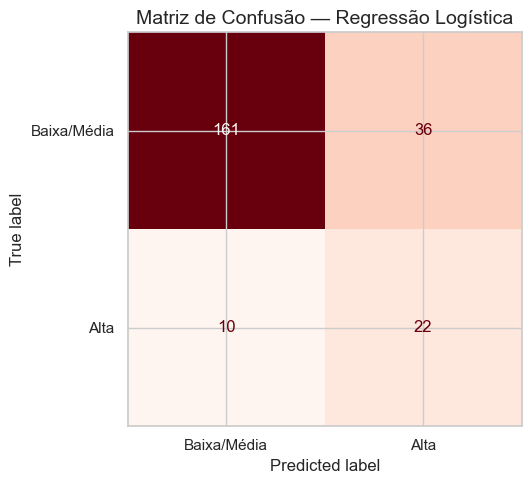

In [73]:
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]
roc_auc_log = avaliar_modelo(y_test, y_pred_log, y_proba_log, "Regressão Logística", "06")

### 6.3 Modelo 2 — Random Forest

`class_weight='balanced'` aplicado pelo mesmo motivo do modelo anterior.

In [74]:
from sklearn.ensemble import RandomForestClassifier

# Treinamento
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_train, y_train)

# Predições
y_pred_rf = rf.predict(X_test)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


### 6.4 Avaliação — Random Forest

Classification Report — Random Forest
              precision    recall  f1-score   support

 Baixa/Média       0.94      0.92      0.93       197
        Alta       0.58      0.66      0.62        32

    accuracy                           0.89       229
   macro avg       0.76      0.79      0.78       229
weighted avg       0.89      0.89      0.89       229

ROC-AUC: 0.910


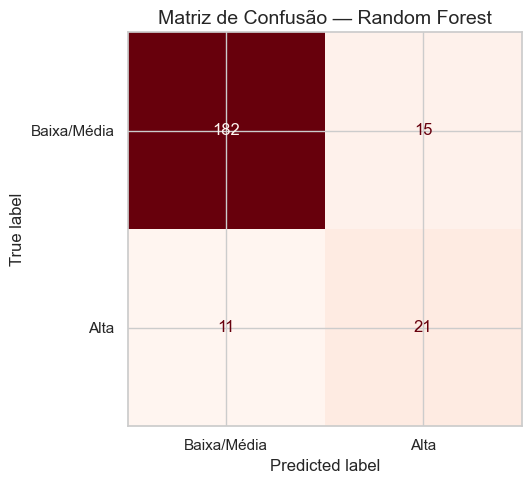

In [75]:
y_proba_rf = rf.predict_proba(X_test)[:, 1]
roc_auc_rf = avaliar_modelo(y_test, y_pred_rf, y_proba_rf, "Random Forest", "07")

### 6.5 Modelo 3 — XGBoost

`scale_pos_weight` calculado manualmente como equivalente ao `class_weight`
usado nos modelos anteriores.

In [76]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Treinamento
xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)

# Predições
y_pred_xgb = xgb.predict(X_test)

print(f"scale_pos_weight calculado: {scale_pos_weight:.2f}")

scale_pos_weight calculado: 6.20


### 6.6 Avaliação — XGBoost

Classification Report — XGBoost
              precision    recall  f1-score   support

 Baixa/Média       0.95      0.93      0.94       197
        Alta       0.61      0.69      0.65        32

    accuracy                           0.90       229
   macro avg       0.78      0.81      0.79       229
weighted avg       0.90      0.90      0.90       229

ROC-AUC: 0.919


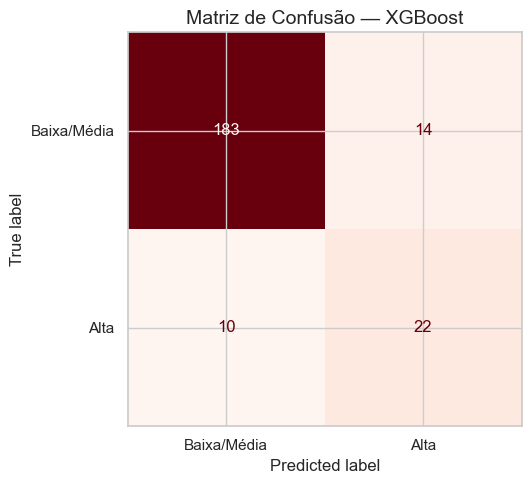

In [77]:
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
roc_auc_xgb = avaliar_modelo(y_test, y_pred_xgb, y_proba_xgb, "XGBoost", "08")

---
## 7. Comparação dos Modelos

Métricas dos três modelos lado a lado, com foco na classe "Alta Qualidade".

In [78]:
comparacao = pd.DataFrame({
    "Modelo": ["Regressão Logística", "Random Forest", "XGBoost"],
    "Precision (Alta)": [0.38, 0.76, 0.61],
    "Recall (Alta)": [0.69, 0.50, 0.69],
    "F1-Score (Alta)": [0.49, 0.60, 0.65],
    "ROC-AUC": [roc_auc_log, roc_auc_rf, roc_auc_xgb]
})

comparacao = comparacao.round(3)
print(comparacao.to_string(index=False))

comparacao.to_csv("../results/metrics/comparacao_modelos.csv", index=False)

             Modelo  Precision (Alta)  Recall (Alta)  F1-Score (Alta)  ROC-AUC
Regressão Logística              0.38           0.69             0.49    0.850
      Random Forest              0.76           0.50             0.60    0.910
            XGBoost              0.61           0.69             0.65    0.919


---
## 8. Interpretação dos Resultados

Extração da importância de features do modelo XGBoost (melhor desempenho),
identificando quais variáveis mais influenciam a classificação
de qualidade.

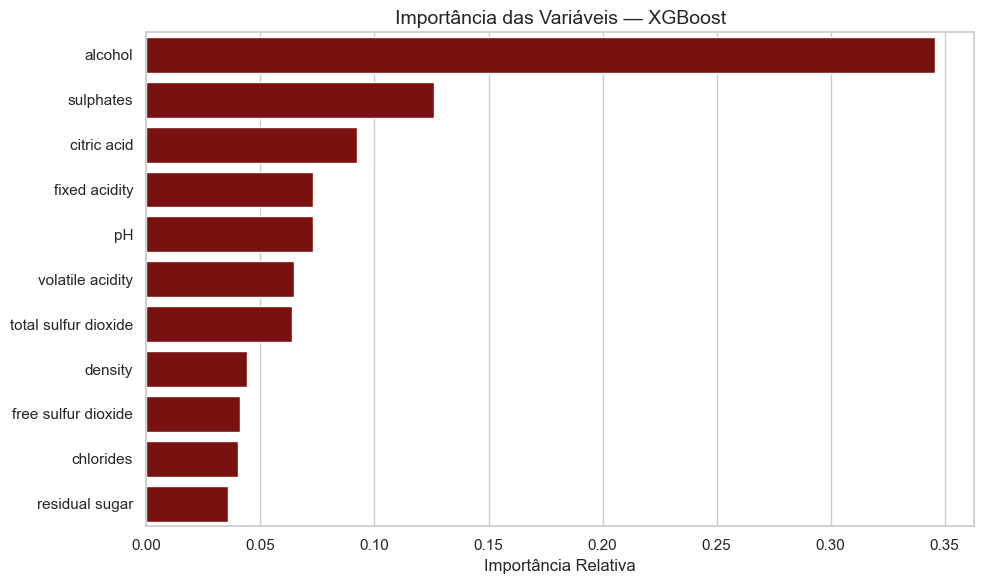

             Feature  Importância
             alcohol     0.345620
           sulphates     0.126153
         citric acid     0.092340
       fixed acidity     0.072983
                  pH     0.072982
    volatile acidity     0.064603
total sulfur dioxide     0.064046
             density     0.044128
 free sulfur dioxide     0.041228
           chlorides     0.040055
      residual sugar     0.035863


In [79]:
importancias = pd.DataFrame({
    "Feature": X.columns,
    "Importância": xgb.feature_importances_
}).sort_values("Importância", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importancias, x="Importância", y="Feature", 
            color="#8B0000", ax=ax)
ax.set_title("Importância das Variáveis — XGBoost")
ax.set_xlabel("Importância Relativa")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("../results/figures/09_feature_importance.png", dpi=300)
plt.show()

print(importancias.to_string(index=False))

**Interpretação — Importância das Variáveis:**

As três variáveis mais influentes segundo o XGBoost foram `alcohol`, `sulphates`
e `citric acid` — coincidindo com o que já tinha aparecido na correlação e nos
boxplots por classe.

Importância de feature mede contribuição dentro do modelo treinado, considerando
interações entre variáveis — é diferente da correlação simples calculada na EDA.
A convergência entre os dois métodos reforça o achado, mas isso ainda é associação
estatística, não causalidade.